# Figures 6-7: NANOGrav 15yr broken-power-law fit

Reproduces `pta_posterior.pdf` (Fig. 6) and `pta_corner.pdf` (Fig. 7),
reading the already-sampled MCMC chains `data/chain_pta_bpl_{rd,qcd}.npz`.

Regenerating those chains from scratch (not needed to run this notebook):
```
python3 ../export_kernels_ng15.py        # ~1h, writes data/kernels_ng15.npz
python3 ../mcmc_pta_bpl.py rd             # ~70 min each, writes
python3 ../mcmc_pta_bpl.py qcd            #   data/chain_pta_bpl_{rd,qcd}.npz
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../core"))
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import corner
from matplotlib.colors import to_rgba

import plotstyle; plotstyle.use_latex()
import mcmc_pta_bpl as M

DATA = os.path.abspath("../data")
FIGDIR = os.path.abspath("../../Draft/Figures")

ch = {m: np.load(os.path.join(DATA, f"chain_pta_bpl_{m}.npz")) for m in ("rd", "qcd")}
cols = {"rd": "crimson", "qcd": "navy"}
names = {"rd": r"radiation domination", "qcd": r"QCD crossover"}

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta) (g_rho, g_s, w from lattice_gstar.py)...
  norm = 1.0032620737


## Figure 6: 2D posterior + posterior-predictive spectrum

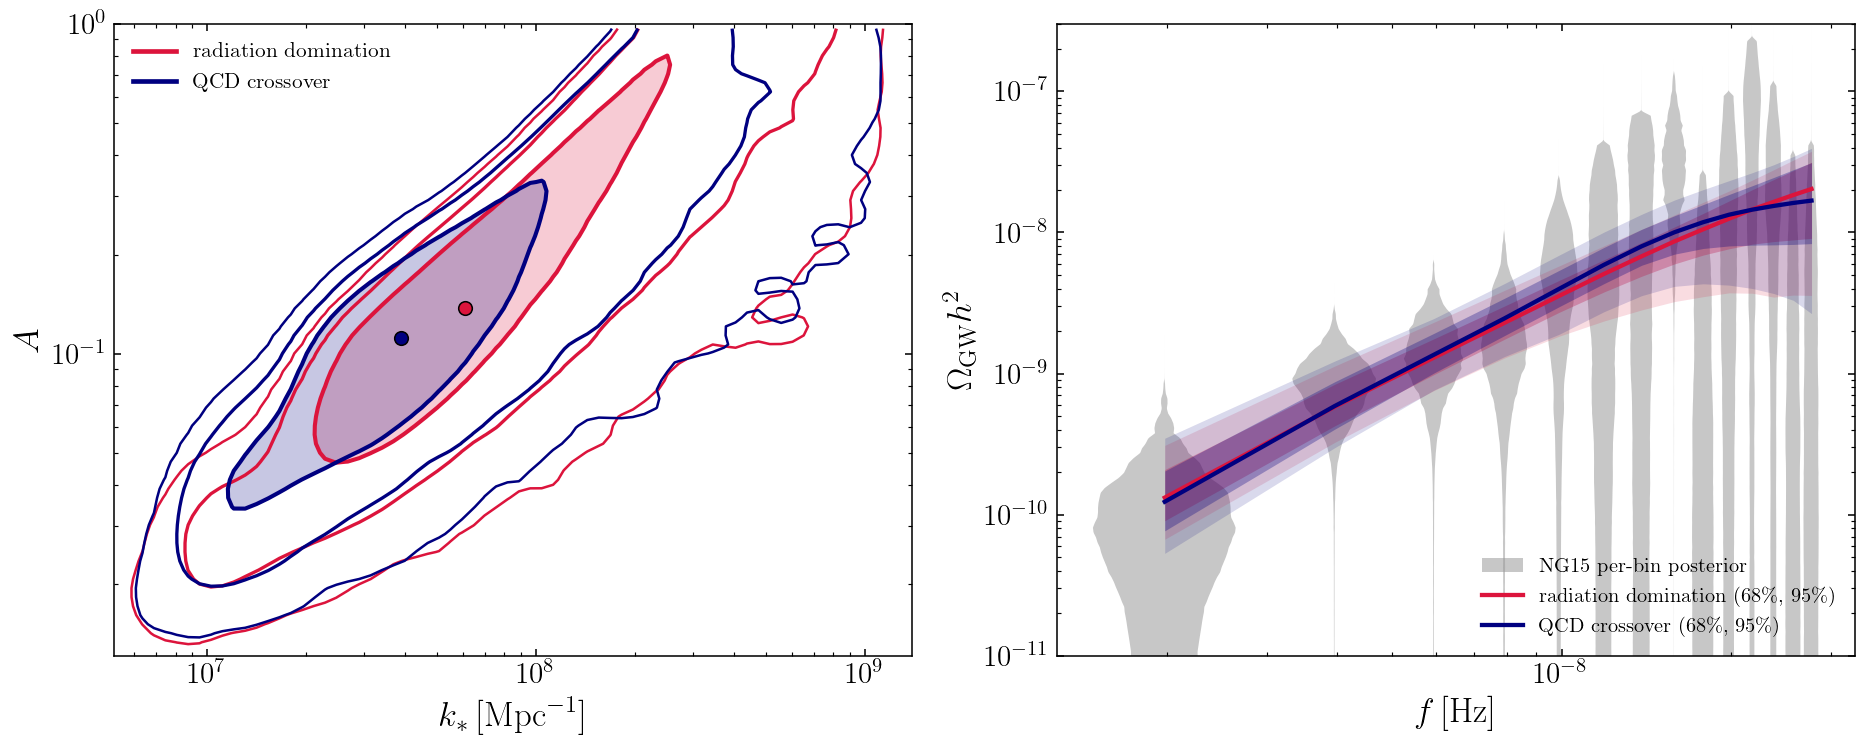

saved pta_posterior.pdf/.png


In [2]:
plt.rcParams.update({"font.size": 15, "axes.labelsize": 18, "axes.titlesize": 16,
                     "legend.fontsize": 13, "xtick.labelsize": 15, "ytick.labelsize": 15})


def hpd_levels(H, probs=(0.68, 0.95, 0.997)):
    """Density levels enclosing the given posterior mass."""
    h = np.sort(H.ravel())[::-1]
    c = np.cumsum(h) / h.sum()
    return [h[np.searchsorted(c, p)] for p in probs][::-1]


fig, ax = plt.subplots(1, 2, figsize=(13.6, 5.6))

allc = np.vstack([ch[m]["chain"] for m in ("rd", "qcd")])
xr = np.percentile(allc[:, 1], [0.2, 99.8]); yr = np.percentile(allc[:, 0], [0.2, 99.8])
px, py = 0.10 * (xr[1] - xr[0]), 0.10 * (yr[1] - yr[0])
rng = [[xr[0] - px, xr[1] + px], [yr[0] - py, min(yr[1] + py, 0.0)]]
for m in ("rd", "qcd"):
    c = ch[m]["chain"]
    H, xe, ye = np.histogram2d(c[:, 1], c[:, 0], bins=70, range=rng, density=True)
    H = gaussian_filter(H, 1.2)
    X, Y = 0.5 * (xe[1:] + xe[:-1]), 0.5 * (ye[1:] + ye[:-1])
    lv = hpd_levels(H)
    Xk, Yk = 10.0 ** X, 10.0 ** Y
    ax[0].contourf(Xk, Yk, H.T, levels=[lv[-1], H.max()], colors=cols[m], alpha=0.22)
    ax[0].contour(Xk, Yk, H.T, levels=lv, colors=cols[m], linewidths=(1.3, 1.7, 2.1))
    ax[0].plot([], [], color=cols[m], lw=2.4, label=names[m])
    med = np.median(c, axis=0)
    ax[0].plot(10.0 ** med[1], 10.0 ** med[0], "o", color=cols[m], ms=7, mec="k", mew=0.8, zorder=5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel(r"$k_\ast\,[\mathrm{Mpc}^{-1}]$")
ax[0].set_ylabel(r"$A$")
ax[0].set_xlim(10.0 ** rng[0][0], 10.0 ** rng[0][1])
ax[0].set_ylim(10.0 ** rng[1][0], 10.0 ** rng[1][1])
ax[0].legend(loc="upper left", fontsize=11)

fNG, Ag, logL = M.load_likelihood()
L = np.exp(logL - logL.max(axis=1, keepdims=True))
y_of_A = lambda a: 10.0 ** (a - M.LOG_SHIFT)

lf = np.log10(fNG)
gap = np.diff(lf)
halfw = 0.42 * np.concatenate([[gap[0]], np.minimum(gap[:-1], gap[1:]), [gap[-1]]])
for i in range(14):
    w = halfw[i] * L[i] / L[i].max()
    ax[1].fill_betweenx(y_of_A(Ag), 10.0 ** (lf[i] - w), 10.0 ** (lf[i] + w),
                        color="0.6", alpha=0.55, lw=0,
                        label=(r"NG15 per-bin posterior" if i == 0 else None))
for m in ("rd", "qcd"):
    QW, LNKU, LNKV, _ = M.build_quadrature(m)
    c = ch[m]["chain"]
    idx = np.random.default_rng(0).choice(len(c), size=min(4000, len(c)), replace=False)
    om = np.vstack([M.omega_of_theta(c[idx[j:j + 200]], QW, LNKU, LNKV)
                    for j in range(0, len(idx), 200)])
    q = np.percentile(om, [2.5, 16, 50, 84, 97.5], axis=0)
    ax[1].fill_between(ch[m]["f_Hz"], q[0], q[4], color=cols[m], alpha=0.15, lw=0)
    ax[1].fill_between(ch[m]["f_Hz"], q[1], q[3], color=cols[m], alpha=0.30, lw=0)
    ax[1].plot(ch[m]["f_Hz"], q[2], "-", lw=2.2, color=cols[m], label=names[m] + r" ($68\%$, $95\%$)")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel(r"$f\,[\mathrm{Hz}]$")
ax[1].set_ylabel(r"$\Omega_{\rm GW}h^2$")
ax[1].set_ylim(1e-11, 3e-7)
ax[1].legend(loc="lower right", fontsize=10.5)

fig.tight_layout()
for e in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"pta_posterior.{e}"), dpi=160)
plt.show()
print("saved pta_posterior.pdf/.png")

## Figure 7: full 4-parameter posterior

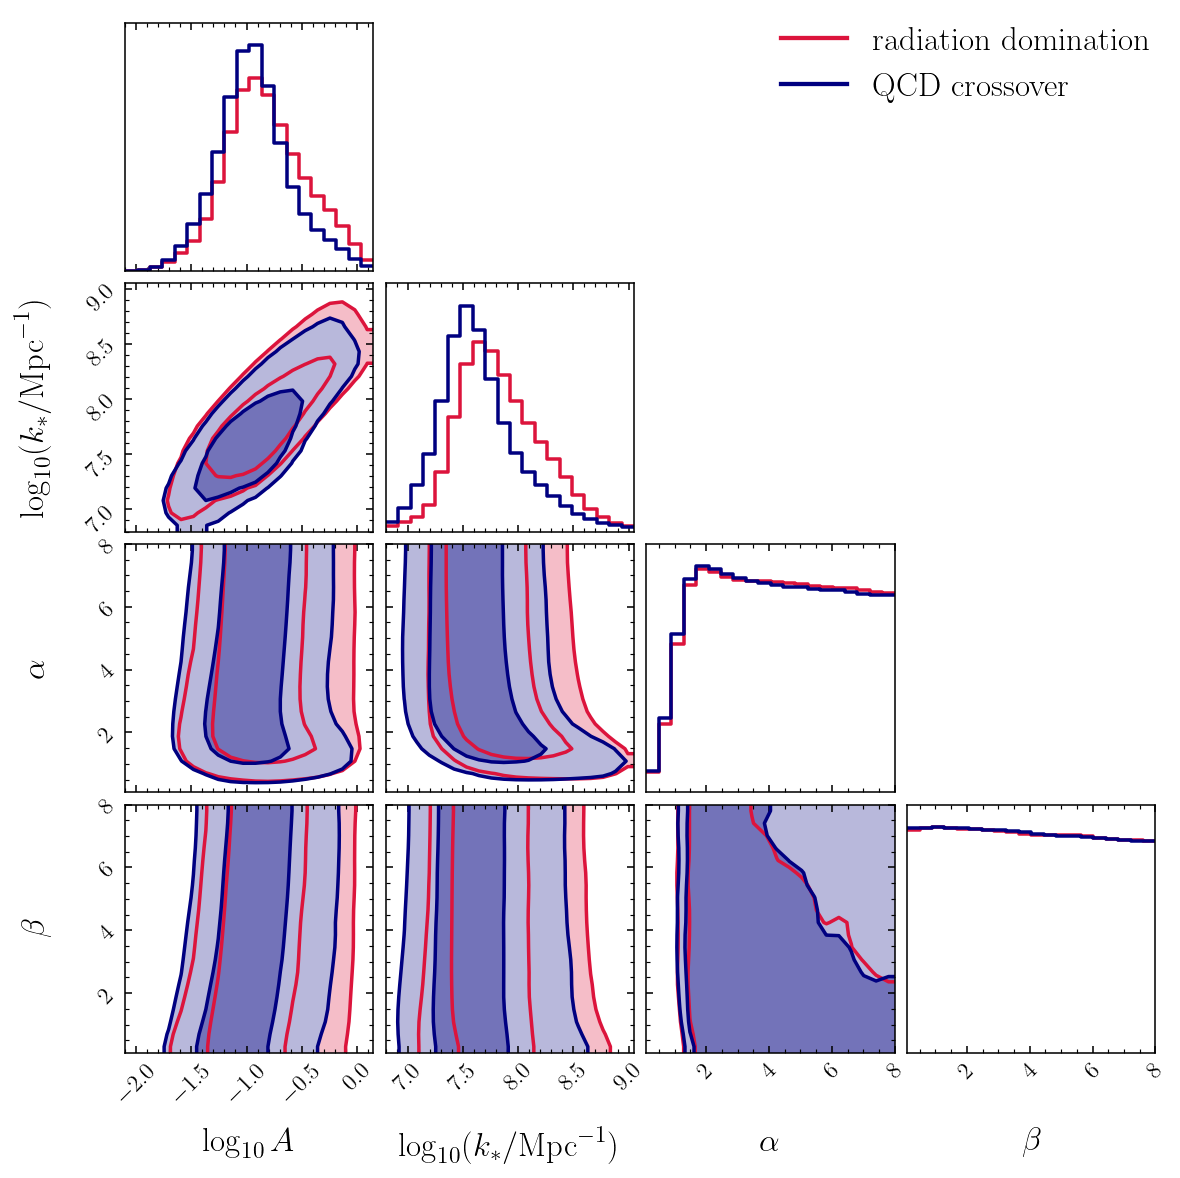

saved pta_corner.pdf


In [3]:
plt.rcParams.update({
    "font.size": 15, "axes.labelsize": 17, "legend.fontsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
})
LABELS = [r"$\log_{10}A$", r"$\log_{10}(k_\ast/{\rm Mpc}^{-1})$", r"$\alpha$", r"$\beta$"]


def band_colors(color, alphas=(0.0, 0.28, 0.55)):
    r, g, b, _ = to_rgba(color)
    return [(r, g, b, a) for a in alphas]


rd = ch["rd"]["chain"]
qcd_c = ch["qcd"]["chain"]
rng4 = [(-2.1, 0.15), (6.8, 9.05), (0.1, 8.0), (0.1, 8.0)]

fig = corner.corner(
    rd, labels=LABELS, range=rng4, color="crimson",
    hist_kwargs={"lw": 1.8},
    plot_datapoints=False, plot_density=False, fill_contours=True,
    levels=(0.68, 0.95), contour_kwargs={"linewidths": 1.8},
    contourf_kwargs={"colors": band_colors("crimson")},
    smooth=1.0, smooth1d=1.0,
)
corner.corner(
    qcd_c, fig=fig, labels=LABELS, range=rng4, color="navy",
    hist_kwargs={"lw": 1.8},
    plot_datapoints=False, plot_density=False, fill_contours=True,
    levels=(0.68, 0.95), contour_kwargs={"linewidths": 1.8},
    contourf_kwargs={"colors": band_colors("navy")},
    smooth=1.0, smooth1d=1.0,
)

fig.set_size_inches(8.6, 8.6)
fig.legend(
    handles=[
        plt.Line2D([], [], color="crimson", lw=2.2, label="radiation domination"),
        plt.Line2D([], [], color="navy", lw=2.2, label="QCD crossover"),
    ],
    loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=17, frameon=False,
)
fig.savefig(os.path.join(FIGDIR, "pta_corner.pdf"), dpi=200, bbox_inches="tight")
plt.show()
print("saved pta_corner.pdf")